torch.Size([64, 27])
torch.Size([64])
torch.Size([64, 27])
torch.Size([64])
Sentiment
2    63657
3    26253
1    21878
4     7311
0     5683
Name: count, dtype: int64
Sentiment
2    15925
3     6674
1     5395
4     1895
0     1389
Name: count, dtype: int64
Epoch [1/10] Train Loss:1.1424 Train Acc:0.5484 Valid Loss:1.0865 Valid Acc:0.5656
保存最佳模型
Epoch [2/10] Train Loss:0.9433 Train Acc:0.6204 Valid Loss:1.0377 Valid Acc:0.5908
保存最佳模型
Epoch [3/10] Train Loss:0.8424 Train Acc:0.6586 Valid Loss:1.0294 Valid Acc:0.6029
保存最佳模型
Epoch [4/10] Train Loss:0.7842 Train Acc:0.6812 Valid Loss:1.0301 Valid Acc:0.6037
保存最佳模型
Epoch [5/10] Train Loss:0.7449 Train Acc:0.6972 Valid Loss:1.0238 Valid Acc:0.6076
保存最佳模型
Epoch [6/10] Train Loss:0.7147 Train Acc:0.7104 Valid Loss:1.0454 Valid Acc:0.6078
保存最佳模型
Epoch [7/10] Train Loss:0.6889 Train Acc:0.7189 Valid Loss:1.0591 Valid Acc:0.6019
Epoch [8/10] Train Loss:0.6668 Train Acc:0.7277 Valid Loss:1.0614 Valid Acc:0.6073
Epoch [9/10] Train Loss:0.6478 Train

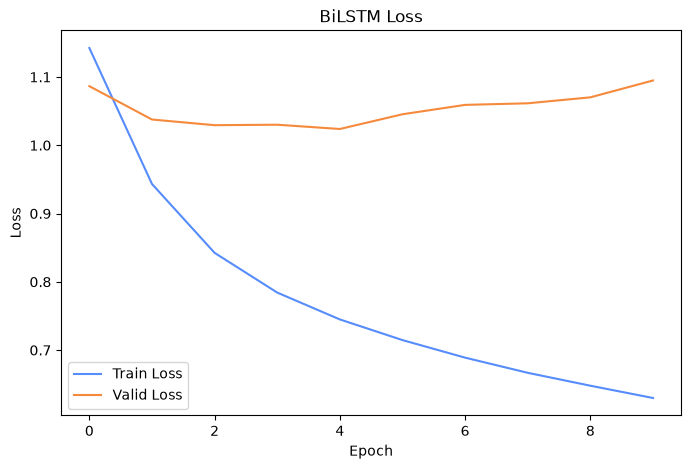

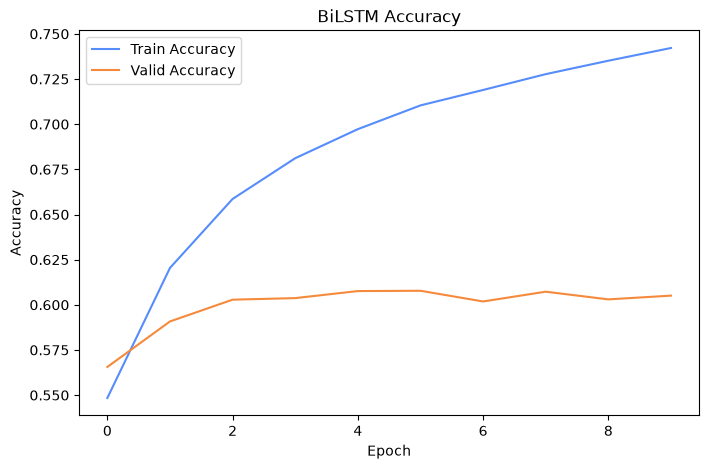

加载最佳模型完成


In [2]:
import pandas as pd
import torch
import torch.nn as nn
import random
# 用来统计单词频率
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(42)
random.seed(42)
torch.cuda.manual_seed(42)
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
train_path = 'train.tsv.zip'

# 为什么这里要用 sep='\t',\t表示制表符，而tsv形式是  a   b   c,
# 告诉pandas我们这里是用 Tab键分隔，不是用逗号
train_df = pd.read_csv(train_path,sep='\t')

train_df['Sentiment'].value_counts()
# train_df["Phrase"].apply(函数) 意思是这一列每个元素都执行这个函数
# 对 phrase 这一列里面的每一句话，把它按空格拆成单词，统计单词数量
# 为后面seq长度和padding做准备
lengths = train_df['Phrase'].apply(
    # lambda 匿名函数
    # split 按空格切割字符串
    lambda x : len(x.split())
)

# 统计所有单词
# 创建一个空的计数器
# 下面自动生成’词频统计表‘，类似一个特殊字典
word_counter = Counter()
# 遍历每一句评论
for sentence in train_df['Phrase']:
    # 转小写
    sentence = sentence.lower()

    # 按空格切割
    words = sentence.split()

    # 加入统计器
    word_counter.update(words)


# 下面进行 Counter -> Vocabulary -> 单词编号
word_to_idx = {}
# 加入两个特殊 token
# <PAD> 负责填充，为embedding做准备
# <UNK> 负责表示训练集里面没有的元素
# 因为后面padding会大量使用它，所以<PAD>为0
word_to_idx['<PAD>'] = 0
word_to_idx['<UNK>'] = 1

# 给单词编号,遍历上面生成的词频统计表,把高词频的放在前面
for word,count in word_counter.most_common():
    # 给单词编号
    word_to_idx[word] = len(word_to_idx)

# 将句子转化为张量
def textToTensor(text,vocab):
    # 转小写
    text = text.lower()

    # 按空格切分
    words = text.split()

    # 保存编号
    indices = []
    for word in words:
        # 先判断里面是否有改单词
        if word in vocab:
            indices.append(word_to_idx[word])
        else:
            indices.append(word_to_idx['<UNK>'])
    return torch.tensor(indices)
class MovieDataset(Dataset):
    def __init__(self,dataframe,vocab):
        # 保存文本
        self.texts = dataframe['Phrase'].values

        # 保存标签
        self.labels = dataframe['Sentiment'].values

        # 保存词表
        self.vocab = vocab
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, index):
        # 取一句话
        text= self.texts[index]

        # 转数字
        text_tensor = textToTensor(text,self.vocab)

        # 标签
        label = self.labels[index]
        return text_tensor,label
#  现在虽然能把句子转化成tensor
# 但是有一个问题，不同的句子转化成的tensor长度不一样，batch要求必须是规则矩阵
# 所以我们需要进行padding操作
# 这和在Dataset里面padding的好处是，dataset不知道这一批最长是多少
def collate_fn(batch):

    # batch里面是很多个（dataset返回的东西）
    # 例如：
    # [
    # (tensor([4,20]),2),
    # (tensor([21,20,11]),3)
    # ]
    texts = []
    labels = []

    for text,label in batch:
        texts.append(text)
        labels.append(label)
    # padding
    # 找到这一批数据里面最长的序列，如何让其他序列补到一样长
    texts = pad_sequence(
        texts,
        # pad_sequence默认输出【sequence_length,batch_size】,也就是维度一为时间步
        # 但是LSTM常用batch_first = True,要求【batch_size,seq_len】
        batch_first=True,
        # 意思是用字典序列的第零位<PAD>来补
        padding_value=0,
    )
    labels = torch.tensor(labels)
    return texts,labels

class BiLSTMClassifier(nn.Module):
    def __init__(
            self,
            vocab_size,
            embedding_dim,
            hidden_size,
            num_classes
    ):
        super().__init__()
        #1. Embedding
        # 告诉embedding 第0个向量只是补位，不参与学习
        self.embedding = nn.Embedding(vocab_size,embedding_dim,padding_idx=0)
        # 2.BiLSTM
        self.lstm = nn.LSTM(
            input_size = embedding_dim,
            hidden_size = hidden_size,
            batch_first = True,
            bidirectional = True
        )
        # 3. 分类层
        # 因为双向LSTM输出
        self.fc = nn.Linear(hidden_size *2,num_classes)

        self.dropout = nn.Dropout(0.5)

    def forward(self,x):
        # x
        # [batch,seq_len]
        x = self.embedding(x)
        # x
        # [batch_size,seq_len,embedding_dim]
        output,(hidden,cell) = self.lstm(x)
        # 取正向最后的hidden
        forward_hidden = hidden[-2]

        # 取反向最后的hidden
        backward_hidden = hidden[-1]

        # 拼接
        hidden = torch.cat([forward_hidden,backward_hidden],dim=1)
        # 使用 dropout 来减少过拟合
        # 对于文本分类，一般加在拼接后面
        # 因为BiLSTM已经负责提取序列特征，不要太早破坏Embedding信息
        hidden = self.dropout(hidden)
        out = self.fc(hidden)
        return out

# 划分训练集和数据集
# 这里不能随机划分，否则会造成数据泄漏
# 应该按照 SentenceId来划分

#取所有SentenceId
sentence_ids = train_df['SentenceId'].unique()
random.seed(42)
random.shuffle(sentence_ids)
split = int(len(sentence_ids) * 0.8)

train_ids = sentence_ids[:split]
valid_ids = sentence_ids[split:]

# 取id读数据
train_df_new = train_df[train_df['SentenceId'].isin(train_ids)]
valid_df = train_df[train_df['SentenceId'].isin(valid_ids)]

train_dataset = MovieDataset(train_df_new,word_to_idx)
valid_dataset = MovieDataset(valid_df,word_to_idx)

# 现在采用动态padding
# 也就是每个batch自己找最大长度
# 而且LSTM可以接受长度变化，[batch_size,seq_len,input_size]
# 因为LSTM 本质： 一个时间步一个时间步读取
# 定义模型
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)
texts,labels = next(iter(train_loader))


print(texts.shape)

print(labels.shape)
texts,labels = next(iter(valid_loader))


print(texts.shape)

print(labels.shape)
print(train_df_new['Sentiment'].value_counts())
print(valid_df['Sentiment'].value_counts())

model = BiLSTMClassifier(
    vocab_size=len(word_to_idx),
    embedding_dim=64,
    hidden_size=64,
    num_classes=5
).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

best_valid_acc = 0


train_losses = []
valid_losses = []

train_accs = []
valid_accs = []

for epoch in range(epochs):

    # ====================
    # Train
    # ====================

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0


    for texts, labels in train_loader:
        texts = texts.to(device)
        labels = labels.to(device)

        # 前向传播
        outputs = model(texts)


        loss = criterion(
            outputs,
            labels
        )


        # 梯度清零
        optimizer.zero_grad()


        # 反向传播
        loss.backward()


        # 更新参数
        optimizer.step()


        # 累计loss
        train_loss += loss.item()



        # 计算准确率

        predictions = outputs.argmax(dim=1)


        train_correct += (
            predictions == labels
        ).sum().item()


        train_total += labels.size(0)



    avg_train_loss = train_loss / len(train_loader)


    train_acc = (
        train_correct / train_total
    )
    # ====================
    # Validation
    # ====================

    model.eval()


    valid_loss = 0
    valid_correct = 0
    valid_total = 0


    with torch.no_grad():

        for texts,labels in valid_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)


            loss = criterion(
                outputs,
                labels
            )


            valid_loss += loss.item()


            predictions = outputs.argmax(dim=1)


            valid_correct += (
                predictions == labels
            ).sum().item()


            valid_total += labels.size(0)



    avg_valid_loss = valid_loss / len(valid_loader)


    valid_acc = (
        valid_correct / valid_total
    )
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)

    train_accs.append(train_acc)
    valid_accs.append(valid_acc)
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss:{avg_train_loss:.4f} "
        f"Train Acc:{train_acc:.4f} "
        f"Valid Loss:{avg_valid_loss:.4f} "
        f"Valid Acc:{valid_acc:.4f}"
    )
    if valid_acc > best_valid_acc:

        best_valid_acc = valid_acc


        torch.save(
            model.state_dict(),
            "best_movie_bilstm.pth"
        )


        print("保存最佳模型")

# 损失Loss
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    valid_losses,
    label="Valid Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("BiLSTM Loss")

plt.legend()

plt.show()

# 准确率 acc
plt.figure(figsize=(8,5))


plt.plot(
    train_accs,
    label="Train Accuracy"
)

plt.plot(
    valid_accs,
    label="Valid Accuracy"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")


plt.title("BiLSTM Accuracy")


plt.legend()

plt.show()

In [9]:
test_path = "test.tsv.zip"

def test_collate_fn(batch):

    texts = []

    for text in batch:
        texts.append(text)

    texts = pad_sequence(
        texts,
        batch_first=True,
        padding_value=0
    )

    return texts

test_df = pd.read_csv(
    test_path,
    sep="\t"
)
test_df['Phrase'] = test_df['Phrase'].fillna("")

class TestDataset(Dataset):

    def __init__(self,dataframe,vocab):

        self.texts = dataframe['Phrase'].values
        self.vocab = vocab


    def __len__(self):

        return len(self.texts)


    def __getitem__(self,index):

        text = self.texts[index]

        text_tensor = textToTensor(
            text,
            self.vocab
        )

        return text_tensor

test_dataset = TestDataset(
    test_df,
    word_to_idx
)


test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=test_collate_fn
)
model.load_state_dict(
    torch.load(
        "best_movie_bilstm.pth",
        weights_only=True
    )
)

model.eval()

predictions = []


with torch.no_grad():

    for texts in test_loader:

        texts = texts.to(device)

        outputs = model(texts)

        preds = outputs.argmax(
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )
submission = pd.DataFrame(
    {
        "PhraseId": test_df["PhraseId"],
        "Sentiment": predictions
    }
)


submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.head())

   PhraseId  Sentiment
0    156061          2
1    156062          2
2    156063          2
3    156064          2
4    156065          2
